# Transient Outburst Light Curve Simulation Pipeline

This notebook demonstrates the two-stage pipeline for generating synthetic **Cataclysmic Variable (CV) / Dwarf Nova (DN)** light curves on Nancy Grace Roman Space Telescope cadences, using OGLE observations as the source data.

In [17]:
import pickle as pkl
import re
from pathlib import Path
from glob import glob
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.signal import find_peaks
from astropy.io import fits
from astropy.table import Table
import george
from george import kernels
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator
from functions import (
    prep_input, prep_gp, fit_gp,
    binning_data, multiscale_peaks, predict_gp,
    get_metrics, l2_distance, find_valid_rows, read_fits
)
from gp_model_params import info
from tqdm.notebook import tqdm
np.random.seed(42)

In [18]:
# Global matplotlib style for paper figures
plt.rcParams.update({
    "font.family"        : "serif",
    "font.size"          : 13,
    "axes.labelsize"     : 14,
    "axes.titlesize"     : 14,
    "legend.fontsize"    : 11,
    "xtick.direction"    : "in",
    "ytick.direction"    : "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "figure.dpi"         : 120,
})

# Color-blind-friendly palette
C0, C1, C2, C3, C4 = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7"

In [19]:
# Paths and source-type configuration
home = str(Path.home())

# Source type: 'CV' for the peak-bank building stage,
#              'DN' for the LC generation stage
TP_BANK = 'CV'    # used when building the peaks bank
TP_GEN  = 'DN'    # used when generating synthetic LCs

DIREC_CV  = home + f'/Research_data/Bulge_Variables/{TP_BANK}/'
DIREC_DN  = home + f'/Research_data/Bulge_Variables/{TP_GEN}/'
OUTPUT_PLOT = f'output/plots/{TP_BANK}/'
OUTPUT_FILE = 'output/'
BAND        = 'I'

Path(OUTPUT_PLOT).mkdir(parents=True, exist_ok=True)
Path(OUTPUT_FILE).mkdir(parents=True, exist_ok=True)

# Multi-scale peak-detection parameters (see multiscale_peaks in functions.py)
PEAK_SCALES        = [0.1, 0.5, 2, 5, 15]   # smoothing scales in days
MIN_SCALES         = 2                        # peak must appear at ≥ this many scales
MERGE_WINDOW       = 5                        # merge peaks within this window (days)
MIN_PROMINENCE     = 0.05                     # minimum peak prominence (mag)
MIN_SEPARATION     = 3.0                      # minimum inter-peak separation (days)
THRESHOLD_MAG      = -0.01                    # clip baseline: mask magnitudes above this
GP_THRESHOLD       = -0.001                   # GP prediction clip for peak templates

print(f"CV data directory : {DIREC_CV}")
print(f"DN data directory : {DIREC_DN}")

CV data directory : /Users/somayeh/Research_data/Bulge_Variables/CV/
DN data directory : /Users/somayeh/Research_data/Bulge_Variables/DN/


## Load Roman Telescope Cadence Arrays

In [20]:
# Load pre-computed Roman Galactic Bulge cadence time arrays
Roman_sampling_short  = np.load('lc_example/roman_times_shortcadence.npy')
Roman_sampling_long   = np.load('lc_example/roman_times_longcadence.npy')
Roman_sampling_long2  = np.load('lc_example/roman_times_longcadence2.npy')

Roman_sampling_short  -= Roman_sampling_short.min()
Roman_sampling_long   -= Roman_sampling_long.min()
Roman_sampling_long2  -= Roman_sampling_long2.min()

Roman_max_short_time = Roman_sampling_short.max()

t_base       = Roman_sampling_short
t_base_long  = Roman_sampling_long
t_base_long2 = Roman_sampling_long2

# Dense regular grid for smooth curve evaluation
t_regular = np.linspace(0, Roman_max_short_time, 750_000)

print(f"Short cadence  : {len(t_base):,} pts  |  span = {Roman_max_short_time:.1f} d")
print(f"Long cadence 1 : {len(t_base_long):,} pts  |  span = {t_base_long.max():.1f} d")
print(f"Long cadence 2 : {len(t_base_long2):,} pts  |  span = {t_base_long2.max():.1f} d")

Short cadence  : 50,700 pts  |  span = 982.0 d
Long cadence 1 : 1,704 pts  |  span = 981.8 d
Long cadence 2 : 1,704 pts  |  span = 981.8 d


## Load a Single OGLE CV Light Curve

OGLE light curves are stored as FITS files with multi-band photometry. We work exclusively in the **I band** here.

CVs/DNe show a characteristic pattern of a flat quiescent baseline punctuated by discrete **outburst events** — brightening of 1–5 mag lasting days to weeks.

In [21]:
# Select one CV FITS file as the worked example
direc_list = np.sort(glob(DIREC_DN + '*.fits'))
print(f"Found {len(direc_list)} DN FITS files.")

# Change the index to inspect a different source
demo_path = direc_list[0]
demo_id   = demo_path.split('/')[-1].split('_')[0]

Found 198 DN FITS files.


In [22]:
# Read the FITS file with the project utility function
# read_fits returns the period (NaN for CVs) and a multi-band DataFrame
# with columns: t (time), m (magnitude), e (error), band
period, df_all = read_fits(demo_path, period=np.nan, tp=TP_GEN)

df = df_all[df_all.band == BAND].reset_index(drop=True)

if df.t.min() > 0:
    df = df.copy()
    df['t'] = df['t'] - df['t'].min()

print(f"I-band data : {len(df):,} points  |  "
      f"span {df.t.min():.1f} – {df.t.max():.1f} days")
print(f"Median quiescent magnitude : {np.median(df.m):.3f}")
df.head()

I-band data : 9,776 points  |  span 0.0 – 4469.9 days
Median quiescent magnitude : 18.341


,t,m,e,phase,band
0,0.00000,18.261,0.069,2.452126e+06,I
1,4.07473,18.217,0.039,2.452130e+06,I
2,7.01630,16.589,0.011,2.452133e+06,I
3,10.92036,18.289,0.056,2.452137e+06,I
4,15.93210,18.218,0.042,2.452142e+06,I


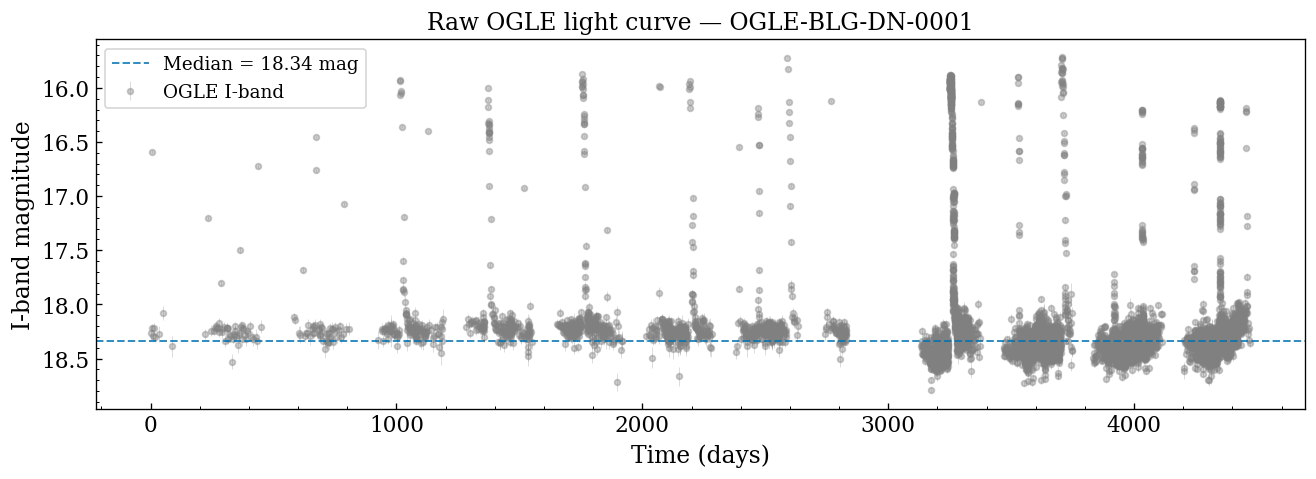

In [23]:
# Raw OGLE I-band light curve
# The characteristic flat quiescent baseline with sporadic bright outbursts
# is the defining photometric signature of DN / CV systems.

fig, ax = plt.subplots(figsize=(13, 4))

ax.errorbar(df.t, df.m, yerr=df.e, fmt='.', color='grey',
            alpha=0.4, ms=7, lw=0.4, zorder=1, label='OGLE I-band')

# Horizontal line marking the median quiescent level
ax.axhline(np.median(df.m), color=C0, lw=1.2, ls='--',
           alpha=0.8, label=f'Median = {np.median(df.m):.2f} mag')

ax.invert_yaxis()
ax.set_xlabel('Time (days)')
ax.set_ylabel('I-band magnitude')
ax.set_title(f'Raw OGLE light curve — {demo_id}')
ax.legend()
ax.xaxis.set_minor_locator(AutoMinorLocator())


## Preprocessing

In [24]:
# Compress large time gaps (> 50 days)
# For CV/DN sources, large observing gaps are removed by shifting later data
# down so the time series appears roughly continuous.
t_min_step = np.min(np.diff(df.t.values))
inds = np.where(np.diff(df.t.values) > 50)[0]

df_modified = df.copy()
for ind in inds:
    time_gap = df_modified.t.iloc[ind + 1] - df_modified.t.iloc[ind] + t_min_step
    df_modified.loc[df_modified.index[ind + 1]:, 't'] -= time_gap

print(f"Gaps compressed: {len(inds)} gap(s) removed.")
print(f"Time span after compression : {df_modified.t.max():.1f} days")

Gaps compressed: 12 gap(s) removed.
Time span after compression : 3005.9 days


In [25]:
# Mask outburst data to create a clean pseudo-baseline
# Points brighter than threshold_mag above the median are replaced with
# the median quiescent level so the GP fit is not influenced by outbursts.

mags          = df_modified.m.values
baseline_mag  = np.percentile(mags, 50)
threshold_mag = THRESHOLD_MAG          # mag above baseline → mask as outburst

y_mags        = mags.copy()
outburst_mask = mags > (threshold_mag + baseline_mag)   # True where outbursting
y_mags[outburst_mask] = baseline_mag

# Subtract median so quiescence = 0.0
y_mags -= np.median(y_mags)
df_modified = df_modified.copy()
df_modified['m'] = y_mags

print(f"Outburst points masked   : {outburst_mask.sum()} / {len(mags)} "
      f"({100*outburst_mask.mean():.1f}%)")

Outburst points masked   : 5189 / 9776 (53.1%)


In [26]:
# Prepare and optionally bin the pseudo-baseline for GP input
info_cv = info[TP_BANK].copy()

x_raw, y_raw, e_raw = prep_input(
    df_modified, TP_BANK, np.nan, info_cv, df_modified.t.max()
)

# Bin if more than 1500 points (keeps GP covariance matrix tractable)
if len(x_raw) > 1500:
    info_cv['fit_binned'] = True
    x_b, y_b, e_b, _ = binning_data(x_raw, y_raw, e_raw, info_cv, n_bins=1500)
else:
    info_cv['fit_binned'] = False
    x_b, y_b, e_b, _ = binning_data(x_raw, y_raw, e_raw, info_cv, n_bins=np.nan)

# Remove NaN errors and apply the threshold a second time on the binned data
valid       = ~np.isnan(e_b)
x_b, y_b, e_b = x_b[valid], y_b[valid], e_b[valid]

baseline_b  = np.percentile(y_b, 50)
y_b_clean   = y_b.copy()
mask_b      = y_b > -0.7           # second threshold on the binned data
y_b_clean[mask_b] = baseline_b
y_b_clean  -= np.median(y_b_clean)

print(f"Binned data: {len(x_b)} points used for peak detection.")

Binned data: 1110 points used for peak detection.


## Multi-scale Peak Detection

`multiscale_peaks` smooths the light curve at several time scales and finds peaks that are consistently detected across at least `min_scales` scales. This suppresses noise spikes (detected only at fine scales) while retaining genuine outbursts (detected at coarser scales too).

The function returns peak times and estimated FWHM widths.

In [27]:
# Run the multi-scale peak detection algorithm
t_peaks, widths = multiscale_peaks(
    x_b, y_b_clean,
    scales        = PEAK_SCALES,
    min_scales    = MIN_SCALES,
    merge_window  = MERGE_WINDOW,
    min_prominence= MIN_PROMINENCE,
    min_separation= MIN_SEPARATION,
)

print(f"Detected {len(t_peaks)} candidate outburst peak(s):")
for t_p, w in zip(t_peaks, widths):
    print(f"  t_peak = {t_p:8.2f} d   FWHM width ≈ {w:.2f} d")

Detected 33 candidate outburst peak(s):
  t_peak =     7.01 d   FWHM width ≈ 2.00 d
  t_peak =    95.19 d   FWHM width ≈ 2.00 d
  t_peak =   229.45 d   FWHM width ≈ 2.00 d
  t_peak =   301.59 d   FWHM width ≈ 2.00 d
  t_peak =   401.79 d   FWHM width ≈ 3.80 d
  t_peak =   518.02 d   FWHM width ≈ 2.00 d
  t_peak =   622.22 d   FWHM width ≈ 14.02 d
  t_peak =   638.25 d   FWHM width ≈ 2.00 d
  t_peak =   738.45 d   FWHM width ≈ 2.00 d
  t_peak =   884.74 d   FWHM width ≈ 16.51 d
  t_peak =   898.76 d   FWHM width ≈ 2.00 d
  t_peak =  1033.03 d   FWHM width ≈ 2.00 d
  t_peak =  1167.29 d   FWHM width ≈ 14.37 d
  t_peak =  1269.49 d   FWHM width ≈ 2.00 d
  t_peak =  1385.72 d   FWHM width ≈ 3.29 d
  t_peak =  1503.95 d   FWHM width ≈ 13.83 d
  t_peak =  1519.98 d   FWHM width ≈ 2.00 d
  t_peak =  1608.16 d   FWHM width ≈ 2.00 d
  t_peak =  1688.31 d   FWHM width ≈ 3.39 d
  t_peak =  1804.54 d   FWHM width ≈ 16.91 d
  t_peak =  1808.55 d   FWHM width ≈ 16.91 d
  t_peak =  1820.57 d   FWHM w

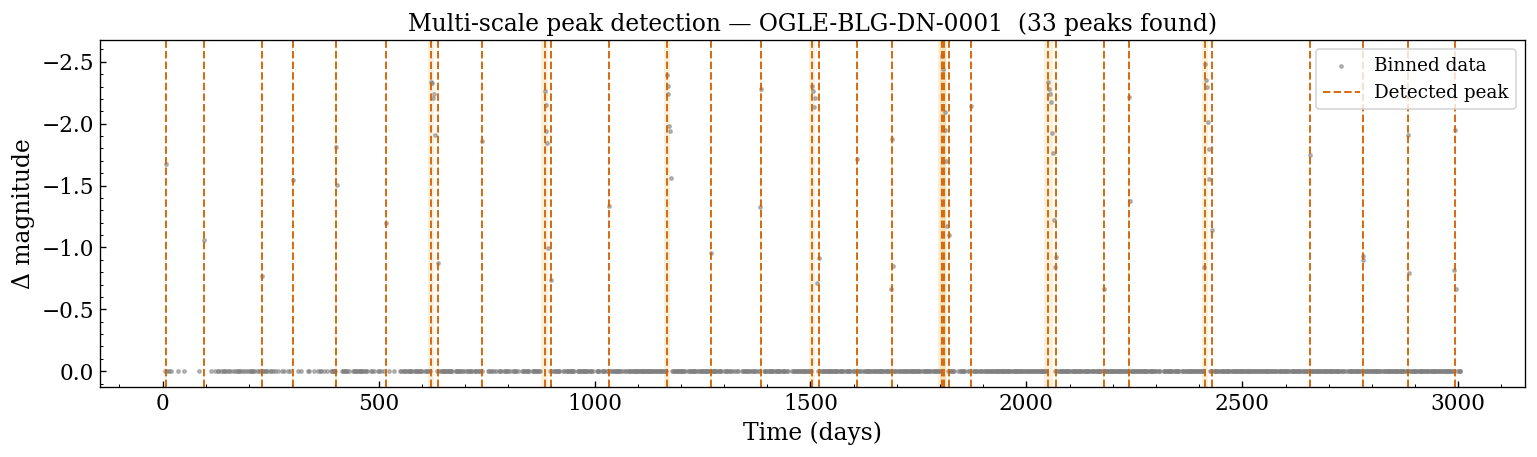

In [28]:
# Multi-scale peak detection on the binned pseudo-baseline
fig, ax = plt.subplots(figsize=(13, 4))

ax.scatter(x_b, y_b_clean, s=4, alpha=0.5, color='grey', zorder=2, label='Binned data')

# Mark each detected peak with a vertical band proportional to its FWHM
for k, (t_p, w) in enumerate(zip(t_peaks, widths)):
    ax.axvspan(t_p - w / 2, t_p + w / 2, alpha=0.15, color=C1, lw=0)
    ax.axvline(t_p, color=C3, lw=1.2, ls='--', alpha=0.9,
               label='Detected peak' if k == 0 else '')

ax.invert_yaxis()
ax.set_xlabel('Time (days)')
ax.set_ylabel('Δ magnitude')
ax.set_title(f'Multi-scale peak detection — {demo_id}  ({len(t_peaks)} peaks found)')
ax.legend()
ax.xaxis.set_minor_locator(AutoMinorLocator())
fig.tight_layout()

## GP Fit to Individual Outburst Profiles

For each detected peak:
1. A window of width $1.5 \times$ FWHM around the peak is extracted
2. A GP is fit using a **log-time axis** (`-log10(t + 0.001)`) to better capture the fast rise / slow decay asymmetry typical of DN outbursts
3. Quality cuts reject fits that are too flat, incomplete (peak at edge of window), or return non-finite predictions
4. Accepted templates are stored in the **peaks bank** with their interpolated dense profiles

In [29]:
# Fit GP templates to each accepted outburst peak
peaks_list = []   # list of peak dictionaries for this source

for j, (t_peak, w) in enumerate(tqdm(
    zip(t_peaks, widths), total=len(t_peaks), desc='Fitting peak GP templates'
)):
    # Quality check 1: skip peaks with unrealistically large widths
    if w > 100:
        print(f"  Peak {j}: width {w:.1f} d too large — skipped.")
        continue

    # Quality check 2: skip likely duplicates (close in time AND width)
    if j < len(t_peaks) - 1:
        if (abs(t_peak - t_peaks[j+1]) < 5) and (abs(w - widths[j+1]) < 0.1):
            print(f"  Peak {j}: duplicate of next peak — skipped.")
            continue

    # Extract the data window around the peak
    dt     = w * 1.5
    ind_pk = (x_b > t_peak - dt) & (x_b < t_peak + dt)
    if ind_pk.sum() == 0:                          # widen window if empty
        ind_pk = (x_b > t_peak - 2.5 * w) & (x_b < t_peak + 2.5 * w)

    t_win = x_b[ind_pk]
    m_win = y_b[ind_pk]   
    e_win = e_b[ind_pk]

    # Quality check 3: require at least 11 data points
    if len(m_win) < 11:
        print(f"  Peak {j}: only {len(m_win)} pts — skipped.")
        continue

    # Fit GP on log-time axis to handle fast-rise / slow-decay asymmetry
    # The log transform compresses the rise and stretches the decay, allowing a
    # stationary GP kernel to capture the asymmetric outburst morphology.
    t_shifted  = t_win - t_win.min()              # local time starts at 0
    x_log      = -1 * np.log10(t_shifted + 0.001) # log-time axis
    x_new      = np.linspace(0, t_win.max() - t_win.min(), int(dt * 10))

    gp = prep_gp(info[TP_BANK], np.nan)
    gp = fit_gp(x_log, m_win, e_win, info[TP_BANK], gp)

    # Predict on the dense linear grid (log-transformed)
    x_new_log   = -1 * np.log10(x_new + 0.001)
    y_pred      = gp.predict(m_win, x_new_log, return_var=True)[0]

    # Quality check 4: non-finite / empty predictions
    if len(y_pred) == 0 or not np.any(np.isfinite(y_pred)):
        print(f"  Peak {j}: GP returned non-finite — skipped.")
        continue

    # Clip GP prediction to zero above threshold (restore flat baseline)
    y_pred_clip = y_pred.copy()
    y_pred_clip[y_pred > GP_THRESHOLD] = 0.0

    # Quality check 5: peak must be significant and complete
    if np.max(y_pred_clip) < -0.1:
        print(f"  Peak {j}: no significant brightening — skipped.")
        continue
    if np.std(y_pred_clip) < 0.3:
        print(f"  Peak {j}: std too low ({np.std(y_pred_clip):.3f}) — skipped.")
        continue
    if y_pred_clip[-1] < -0.5 or y_pred_clip[0] < -0.5:
        print(f"  Peak {j}: peak not complete (edges still bright) — skipped.")
        continue

    # Build interpolator and save to peaks list
    interp_y = interp1d(x_new, y_pred_clip, kind='linear',
                        bounds_error=False, fill_value=np.nan)

    peaks_list.append({
        "gp"       : gp,
        "xfit"     : x_log,           # log-time axis used for fitting
        "yfit"     : m_win,            # raw window magnitudes
        "x"        : t_win,            # original time grid (days)
        "y"        : m_win,
        "e"        : e_win,
        "x_new"    : x_new,            # dense linear time grid (days)
        "y_new"    : y_pred_clip,      # clipped GP prediction
        "interpol" : interp_y,
        "t_peak"   : t_peak,
    })
    print(f"  Peak {j}: ACCEPTED  (t={t_peak:.1f} d, "
          f"min={y_pred_clip.min():.2f}, std={np.std(y_pred_clip):.3f})")

print(f"\nAccepted {len(peaks_list)} / {len(t_peaks)} peaks.")

Fitting peak GP templates:   0%|          | 0/33 [00:00<?, ?it/s]

  Peak 0: only 2 pts — skipped.
  Peak 1: only 1 pts — skipped.
  Peak 2: only 2 pts — skipped.
  Peak 3: only 1 pts — skipped.
  Peak 4: only 4 pts — skipped.
  Peak 5: only 1 pts — skipped.
  Peak 6: peak not complete (edges still bright) — skipped.
  Peak 7: only 3 pts — skipped.
  Peak 8: only 2 pts — skipped.
  Peak 9: ACCEPTED  (t=884.7 d, min=-2.34, std=0.810)
  Peak 10: only 3 pts — skipped.
  Peak 11: only 2 pts — skipped.
  Peak 12: ACCEPTED  (t=1167.3 d, min=-2.52, std=0.895)
  Peak 13: only 3 pts — skipped.
  Peak 14: only 3 pts — skipped.
  Peak 15: ACCEPTED  (t=1504.0 d, min=-2.38, std=0.866)
  Peak 16: only 3 pts — skipped.
  Peak 17: only 2 pts — skipped.
  Peak 18: only 5 pts — skipped.
  Peak 19: duplicate of next peak — skipped.
  Peak 20: ACCEPTED  (t=1808.5 d, min=-2.63, std=0.907)
  Peak 21: only 3 pts — skipped.
  Peak 22: only 1 pts — skipped.
  Peak 23: ACCEPTED  (t=2051.0 d, min=-2.40, std=0.881)
  Peak 24: only 5 pts — skipped.
  Peak 25: only 2 pts — skipped

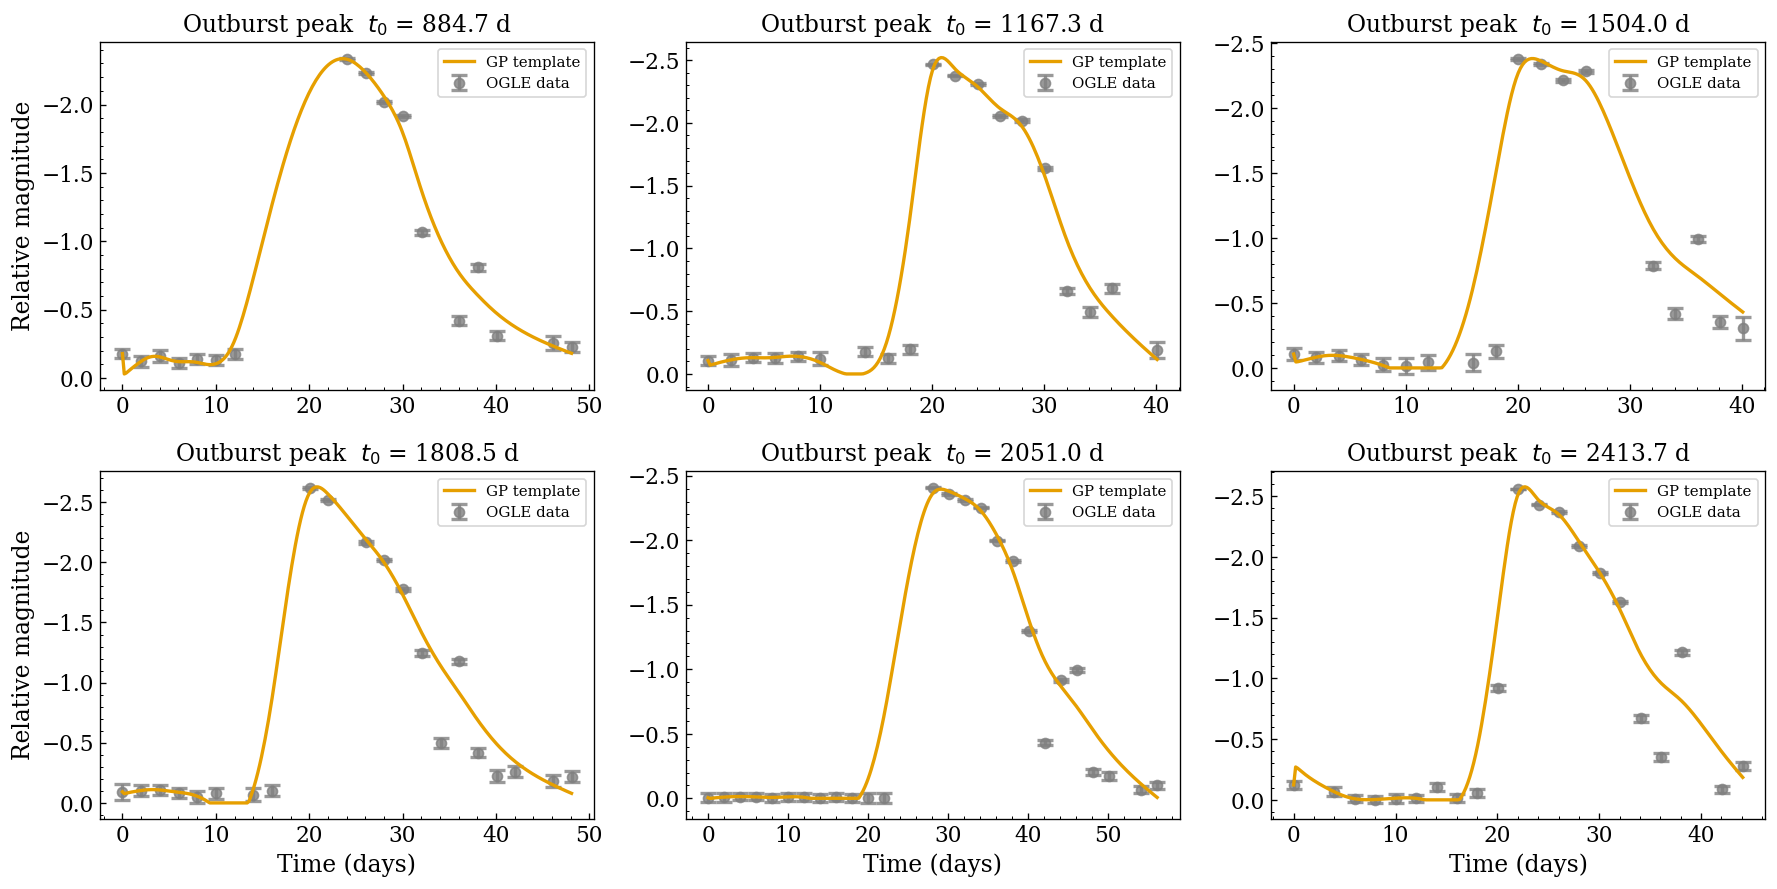

In [30]:
# Gallery of accepted outburst GP templates
n_show = min(len(peaks_list), 6)
ncols  = min(3, n_show)
nrows  = int(np.ceil(n_show / ncols)) if n_show > 0 else 1

if n_show == 0:
    print("No peaks accepted — skipping gallery plot.")
else:
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.8 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, pk in zip(axes, peaks_list[:n_show]):
        t_loc = pk['x'] - pk['x'].min()   # local time axis starting at 0

        ax.errorbar(t_loc, pk['y'], yerr=pk['e'], color='grey',
                   alpha=0.8, zorder=3, 
                    elinewidth=2,    # Thicker vertical lines
                     capsize=5,       # Width of the end caps
                     capthick=2,      # Thickness of the end caps
                     fmt='o', label='OGLE data')
        ax.plot(pk['x_new'], pk['y_new'], color=C1,
                lw=2.0, zorder=4, label='GP template')

        ax.invert_yaxis()
        
        
        
        ax.set_title(f'Outburst peak  $t_0$ = {pk["t_peak"]:.1f} d')
        ax.legend(fontsize=9)
        ax.xaxis.set_minor_locator(AutoMinorLocator())

    for ax in axes[n_show:]:
        ax.set_visible(False)

    axes[0].set_ylabel('Relative magnitude')
    axes[3].set_ylabel('Relative magnitude')
    axes[3].set_xlabel('Time (days)')
    axes[4].set_xlabel('Time (days)')
    axes[5].set_xlabel('Time (days)')
    fig.tight_layout()
    plt.savefig(OUTPUT_PLOT + f'fig4_{demo_id}_peak_gallery.pdf', bbox_inches='tight')
    plt.show()

## Synthetic Roman Light Curve Generation

With the peaks bank built, we now generate synthetic Roman LCs:
1. **Flat quiescent baseline** — constant at the observed median magnitude + small Gaussian noise
2. **Random outburst injection** — $N$ peak templates drawn randomly and injected at random times
3. **All three Roman cadences** are populated simultaneously from the same templates

For each observed DN source, `n_sim_lc_per_obs_lc = 10` synthetic LCs are produced to build statistical diversity.

In [31]:
# Simulation parameters
N_SIM_PER_SOURCE = 3      # number of synthetic LCs to generate (3 for demo)
MAX_N_PEAKS      = 6      # upper bound on injected outbursts per LC
NOISE_AMP        = 0.001  # Gaussian noise amplitude added to baseline (mag)

# Quiescent baseline magnitude (median of the original photometry)
baseline_mag = np.median(df_all.m)
print(f"Quiescent baseline magnitude : {baseline_mag:.3f}")

Quiescent baseline magnitude : 18.340


In [32]:
# Build flat baselines at all three Roman cadences

def flat_baseline(t_arr, mag, noise):
    """Return a flat baseline at `mag` with Gaussian noise of amplitude `noise`."""
    return np.ones_like(t_arr) * mag + np.random.normal(0, noise, size=len(t_arr))

y_base        = flat_baseline(t_base,       baseline_mag, NOISE_AMP)
y_base_long   = flat_baseline(t_base_long,  baseline_mag, NOISE_AMP)
y_base_long2  = flat_baseline(t_base_long2, baseline_mag, NOISE_AMP)
y_base_regular= flat_baseline(t_regular,    baseline_mag, NOISE_AMP)

print("Flat baselines constructed at all four sampling grids.")

Flat baselines constructed at all four sampling grids.


In [33]:
# Generate N_SIM_PER_SOURCE synthetic LCs for the demo source
peaks_bank_demo = {demo_id: peaks_list}
all_peaks_demo = peaks_bank_demo[demo_id]
n_all_peaks    = len(all_peaks_demo)

# Draw the number of peaks for each simulation
max_p   = min(MAX_N_PEAKS, n_all_peaks)
n_peaks = np.random.choice(np.arange(1, max_p + 1, dtype=int), size=N_SIM_PER_SOURCE)

all_lc_demo = {}

for i in tqdm(range(N_SIM_PER_SOURCE), desc='Generating synthetic LCs'):

    lc_id = f'{demo_id}_ind{i}_{n_peaks[i]}peaks'

    # Fresh copy of the flat baseline for each realisation
    y_sim        = flat_baseline(t_base,       baseline_mag, NOISE_AMP)
    y_sim_long   = flat_baseline(t_base_long,  baseline_mag, NOISE_AMP)
    y_sim_long2  = flat_baseline(t_base_long2, baseline_mag, NOISE_AMP)
    y_sim_regular= flat_baseline(t_regular,    baseline_mag, NOISE_AMP)

    # Random injection times drawn from the short-cadence grid
    rand_peak_times = np.random.choice(t_base, size=n_peaks[i])

    # Random peak template indices (sampling with replacement if needed)
    peak_inds = np.random.choice(np.arange(n_all_peaks), size=n_peaks[i])

    injected = []

    for j in range(n_peaks[i]):
        pk  = all_peaks_demo[peak_inds[j]]
        t0  = rand_peak_times[j]

        # Duration before and after peak (for masking the injection window)
        t_of_max = pk['x'][np.argmin(pk['yfit'])]
        dt_left  = t_of_max - pk['x'].min()
        dt_right = pk['x'].max() - t_of_max

        interp_pk = interp1d(
            pk['x_new'], pk['y_new'],
            kind='linear', bounds_error=False, fill_value=np.nan
        )

        def inject(t_arr, y_arr):
            """Inject peak template additively onto y_arr at injection time t0."""
            mask = (t_arr > t0 - dt_left) & (t_arr < t0 + dt_right)
            if mask.sum() == 0:
                return
            # Local time axis: shift so window starts at dt_left
            t_local   = t_arr[mask] - t_arr[mask].min()
            delta_mag = interp_pk(t_local)
            # Align so peak brightening = 0 delta-mag (additive to the baseline)
            y_arr[mask] += delta_mag - np.nanmax(delta_mag)

        inject(t_base,       y_sim)
        inject(t_base_long,  y_sim_long)
        inject(t_base_long2, y_sim_long2)
        inject(t_regular,    y_sim_regular)

        injected.append({'t0': t0, 'dt_left': dt_left, 'dt_right': dt_right,
                         'peak_idx': peak_inds[j]})

    # Store the complete synthetic LC
    all_lc_demo[lc_id] = {
        f'{BAND}_band_t_base_Roman_short'              : t_base,
        f'{BAND}_band_t_base_Roman_long'               : t_base_long,
        f'{BAND}_band_t_base_Roman_long2'              : t_base_long2,
        f'{BAND}_band_Roman_m_official_sampling_short' : y_sim,
        f'{BAND}_band_Roman_m_official_sampling_long'  : y_sim_long,
        f'{BAND}_band_Roman_m_official_sampling_long2' : y_sim_long2,
        f'{BAND}_band_Roman_m_regular_sampling'        : y_sim_regular,
        f'{BAND}_band_Roman_time_regular_sampling'     : t_regular,
        'injected_peaks'                               : injected,
    }

print(f"\nGenerated {len(all_lc_demo)} synthetic light curves.")

Generating synthetic LCs:   0%|          | 0/3 [00:00<?, ?it/s]


Generated 3 synthetic light curves.


## Visualise the Synthetic Light Curves

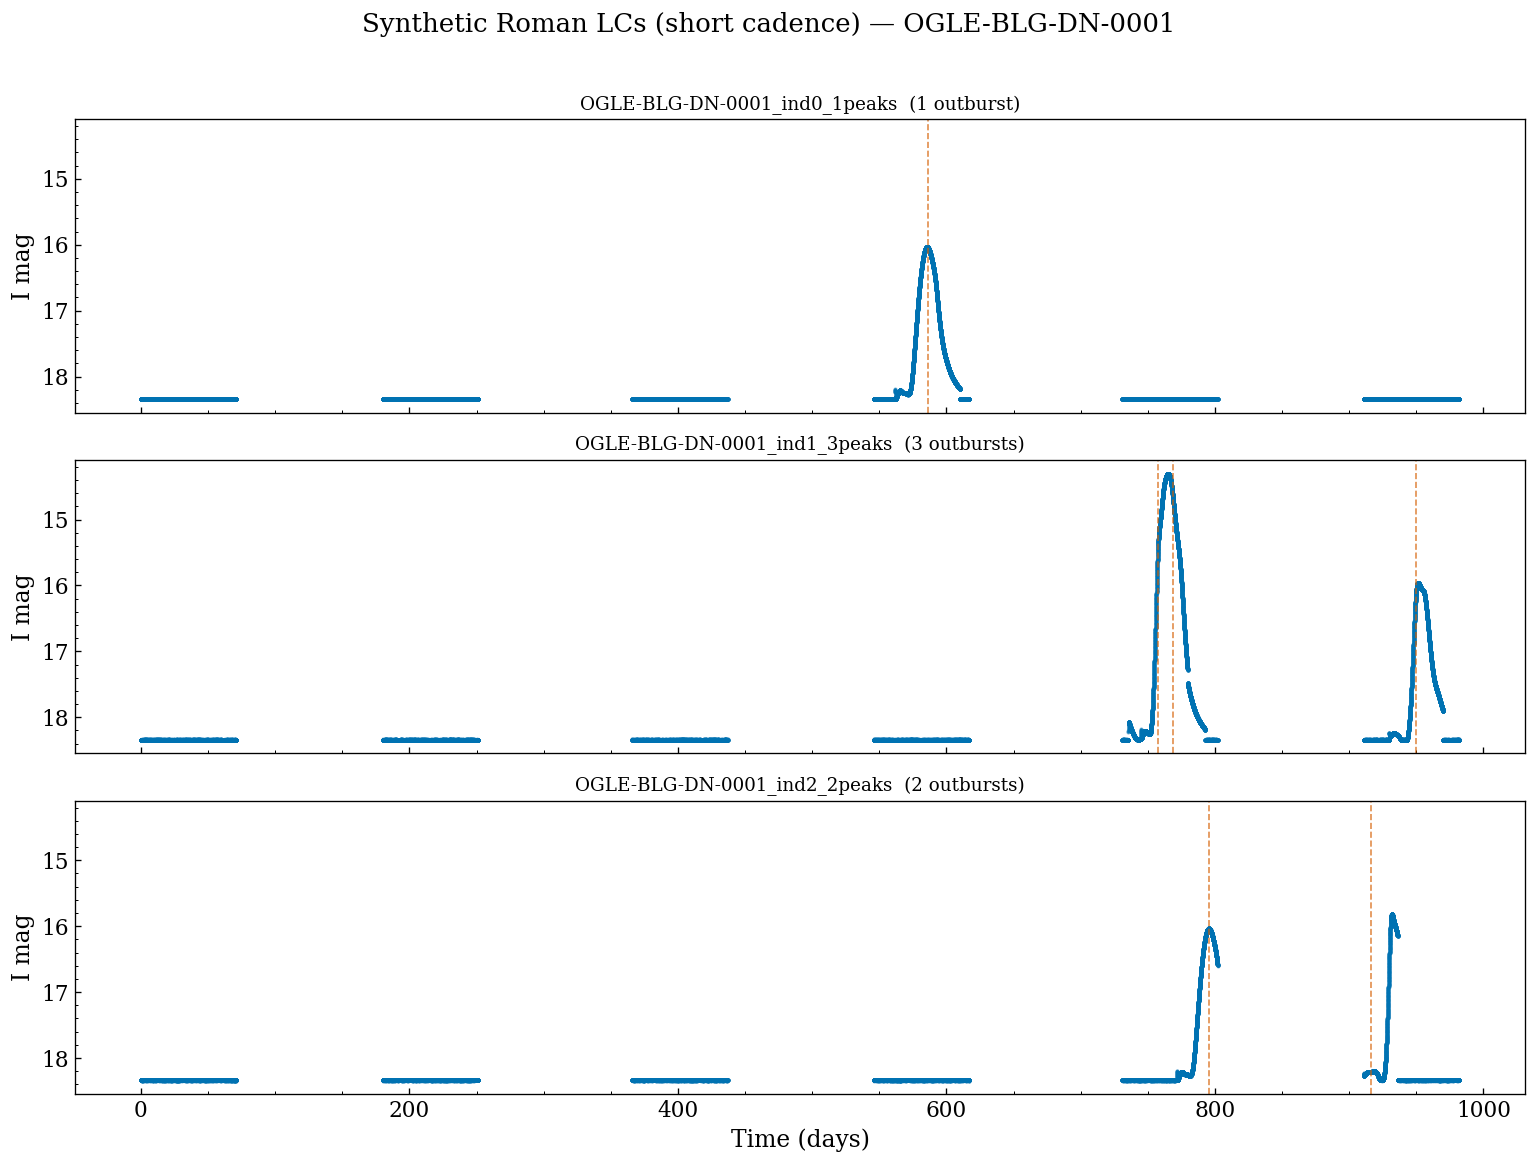

In [34]:
# All synthetic realisations — short cadence
# Each row is one synthetic LC; all share the same baseline magnitude but
# differ in the number, timing, and morphology of injected outbursts.

lc_ids = list(all_lc_demo.keys())

fig, axes = plt.subplots(N_SIM_PER_SOURCE, 1,
                         figsize=(13, 3.2 * N_SIM_PER_SOURCE),
                         sharex=True, sharey=True)
axes = np.atleast_1d(axes)

for ax, lc_id in zip(axes, lc_ids):
    lc   = all_lc_demo[lc_id]
    t_s  = lc[f'{BAND}_band_t_base_Roman_short']
    y_s  = lc[f'{BAND}_band_Roman_m_official_sampling_short']

    ax.scatter(t_s, y_s, s=2, alpha=0.5, color=C0)

    n_inj = len(lc['injected_peaks'])
    for pk_info in lc['injected_peaks']:
        ax.axvline(pk_info['t0'], color=C3, lw=1.0, ls='--', alpha=0.7)

    ax.invert_yaxis()
    ax.set_ylabel('I mag')
    ax.set_title(f'{lc_id}  ({n_inj} outburst{"s" if n_inj>1 else ""})', fontsize=11)
    ax.xaxis.set_minor_locator(AutoMinorLocator())

axes[-1].set_xlabel('Time (days)')
fig.suptitle(f'Synthetic Roman LCs (short cadence) — {demo_id}', y=1.01)
fig.tight_layout()
plt.savefig(OUTPUT_PLOT + f'fig6_{demo_id}_synthetic_realisations.pdf', bbox_inches='tight')
plt.show()

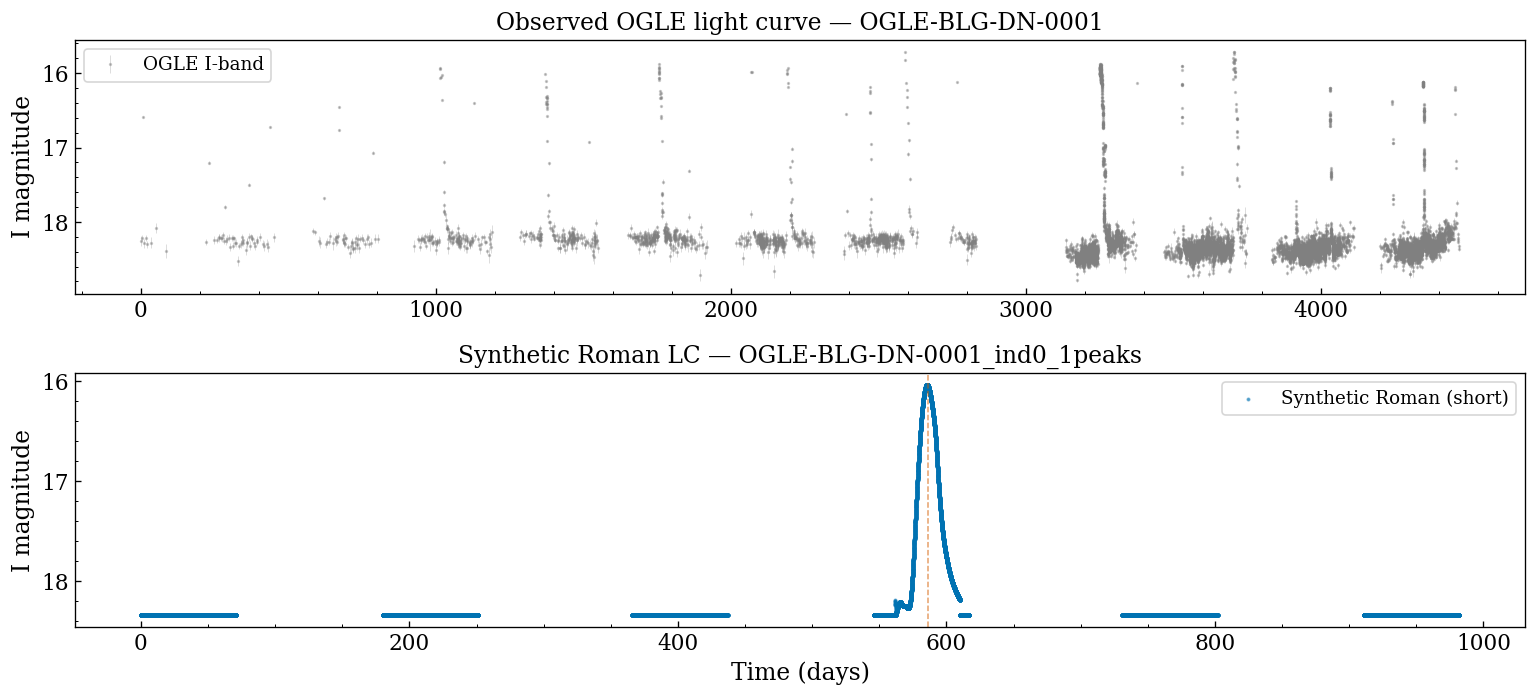

In [35]:
# Original OGLE vs. one synthetic Roman LC (same source)

lc  = all_lc_demo[lc_ids[0]]
t_s = lc[f'{BAND}_band_t_base_Roman_short']
y_s = lc[f'{BAND}_band_Roman_m_official_sampling_short']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 6), sharex=False)

# Original OGLE I-band
ax1.errorbar(df.t, df.m, yerr=df.e, fmt='.', color='grey',
             alpha=0.4, ms=2, lw=0.4, label='OGLE I-band')
ax1.invert_yaxis()
ax1.set_ylabel('I magnitude')
ax1.set_title(f'Observed OGLE light curve — {demo_id}')
ax1.legend()
ax1.xaxis.set_minor_locator(AutoMinorLocator())

# Synthetic Roman LC
ax2.scatter(t_s, y_s, s=2, alpha=0.5, color=C0, label='Synthetic Roman (short)')
for pk_info in lc['injected_peaks']:
    ax2.axvline(pk_info['t0'], color=C3, lw=0.9, ls='--', alpha=0.6)
ax2.invert_yaxis()
ax2.set_ylabel('I magnitude')
ax2.set_xlabel('Time (days)')
ax2.set_title(f'Synthetic Roman LC — {lc_ids[0]}')
ax2.legend()
ax2.xaxis.set_minor_locator(AutoMinorLocator())

fig.tight_layout()
# plt.savefig(OUTPUT_PLOT + f'fig8_{demo_id}_observed_vs_synthetic.pdf', bbox_inches='tight')
# plt.show()